# 🌍 End-to-End Customer Intelligence System
## Unsupervised + Supervised Learning on Country Data

**Author:** Pranav Gour  
**Dataset:** [Unsupervised Learning on Country Data – Kaggle](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)  
**Internship:** Celebal Technologies – CEI Data Science Intern

---

### Objective
Build a complete **Customer Intelligence System** that:
1. Performs **Exploratory Data Analysis (EDA)** to understand socioeconomic patterns
2. Applies **Clustering** (K-Means + DBSCAN) for unsupervised country segmentation
3. Trains **Classification models** (Logistic Regression, Decision Tree, Random Forest, XGBoost) to predict cluster membership
4. Uses **Ensemble Learning** for optimized predictive performance
5. Derives **Actionable Insights** about country development and aid prioritization

### Pipeline Overview
```
Raw Data → EDA → Preprocessing → Clustering → Label Generation → Classification → Ensemble → Insights
```

## 1. Install & Import Libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing & Utilities
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    silhouette_score, davies_bouldin_score, adjusted_rand_score
)

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, BaggingClassifier, AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

RANDOM_STATE = 42
print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 2. Load the Dataset

In [3]:
# ── Option A: Running on Google Colab ──────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# import io
# csv_name = next(iter(uploaded))
# df_raw = pd.read_csv(io.BytesIO(uploaded[csv_name]))

# ── Option B: Local / Kaggle Notebook (recommended) ───────────────────────
df_raw = pd.read_csv('Country-data.csv')

print(f'Dataset shape: {df_raw.shape}')
df_raw.head(10)

Dataset shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 3. Exploratory Data Analysis (EDA)

In [4]:
# ── 3.1 Basic Info ────────────────────────────────────────────────────────
print('=== Dataset Info ===')
print(f'Shape        : {df_raw.shape}')
print(f'Countries    : {df_raw["country"].nunique()}')
print(f'Missing vals : {df_raw.isnull().sum().sum()}')
print(f'Duplicates   : {df_raw.duplicated().sum()}')
print()
df_raw.info()

=== Dataset Info ===
Shape        : (167, 10)
Countries    : 167
Missing vals : 0
Duplicates   : 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
# ── 3.2 Statistical Summary ───────────────────────────────────────────────
df_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','min','max'])

,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


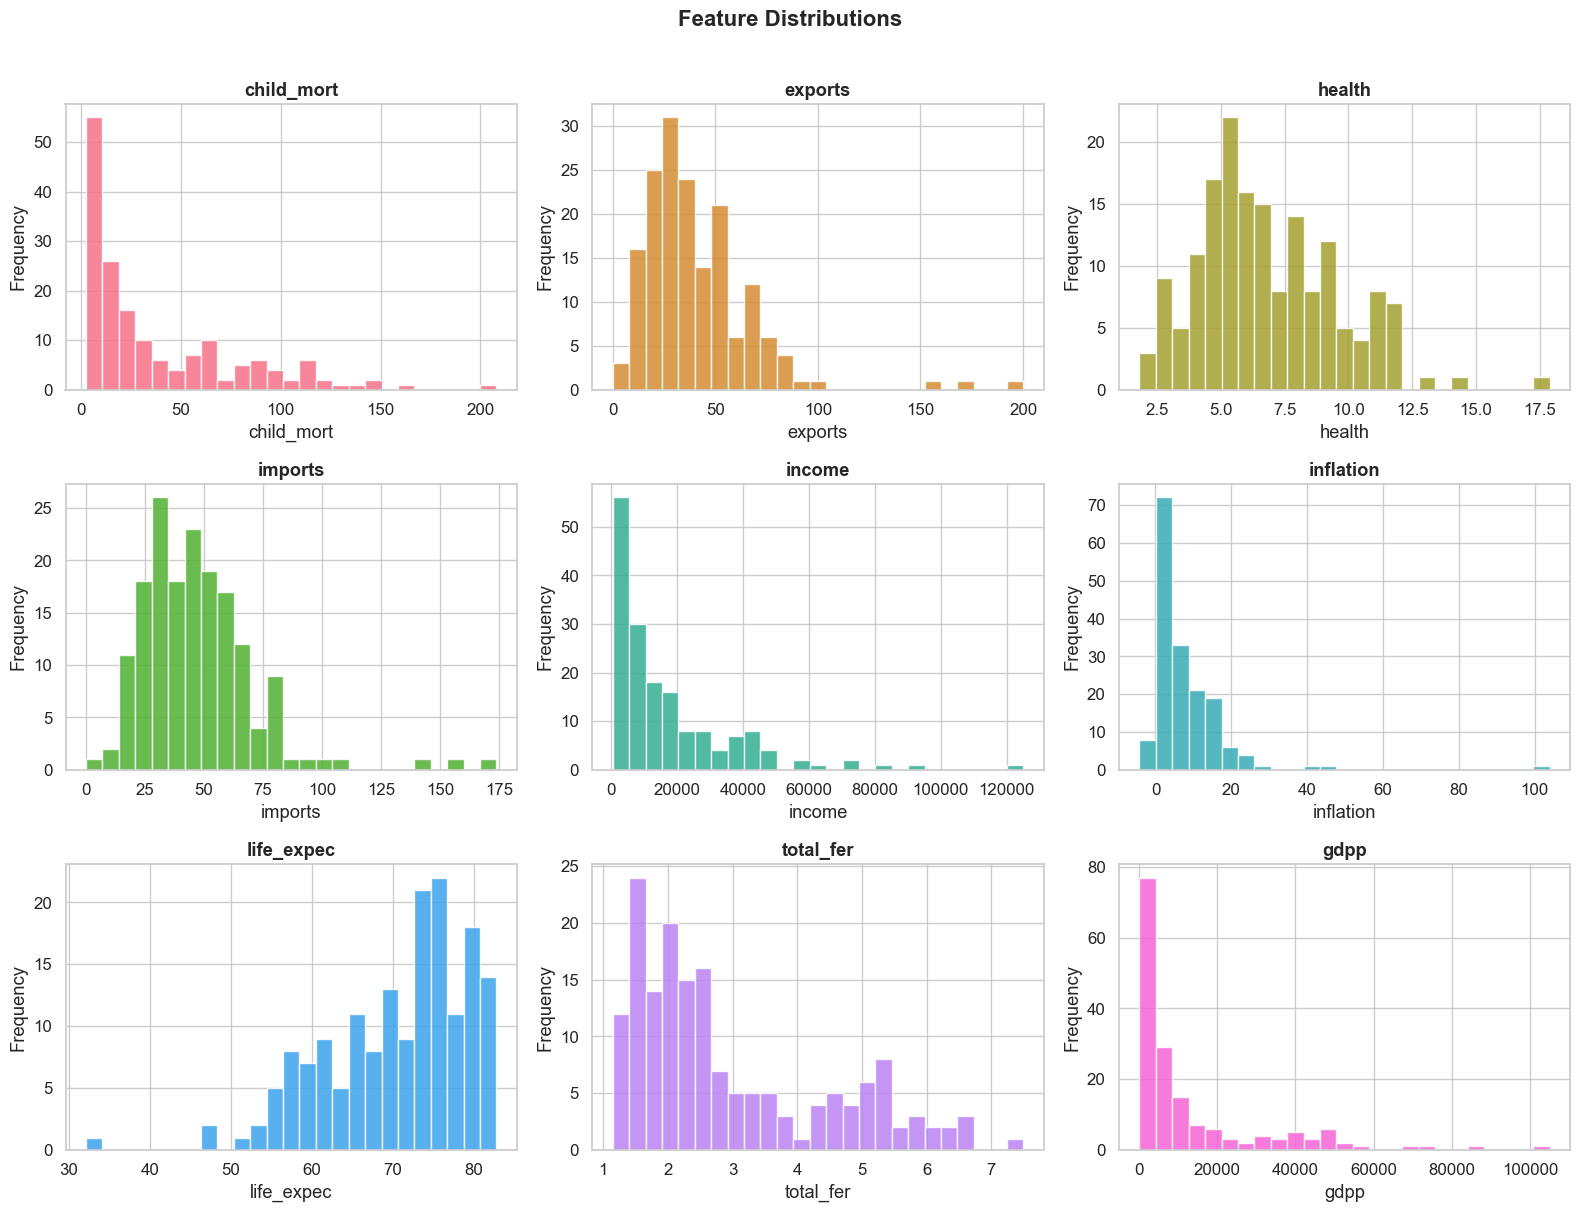

In [6]:
# ── 3.3 Feature Distributions ─────────────────────────────────────────────
numeric_cols = [c for c in df_raw.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
colors = sns.color_palette('husl', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_raw[col], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

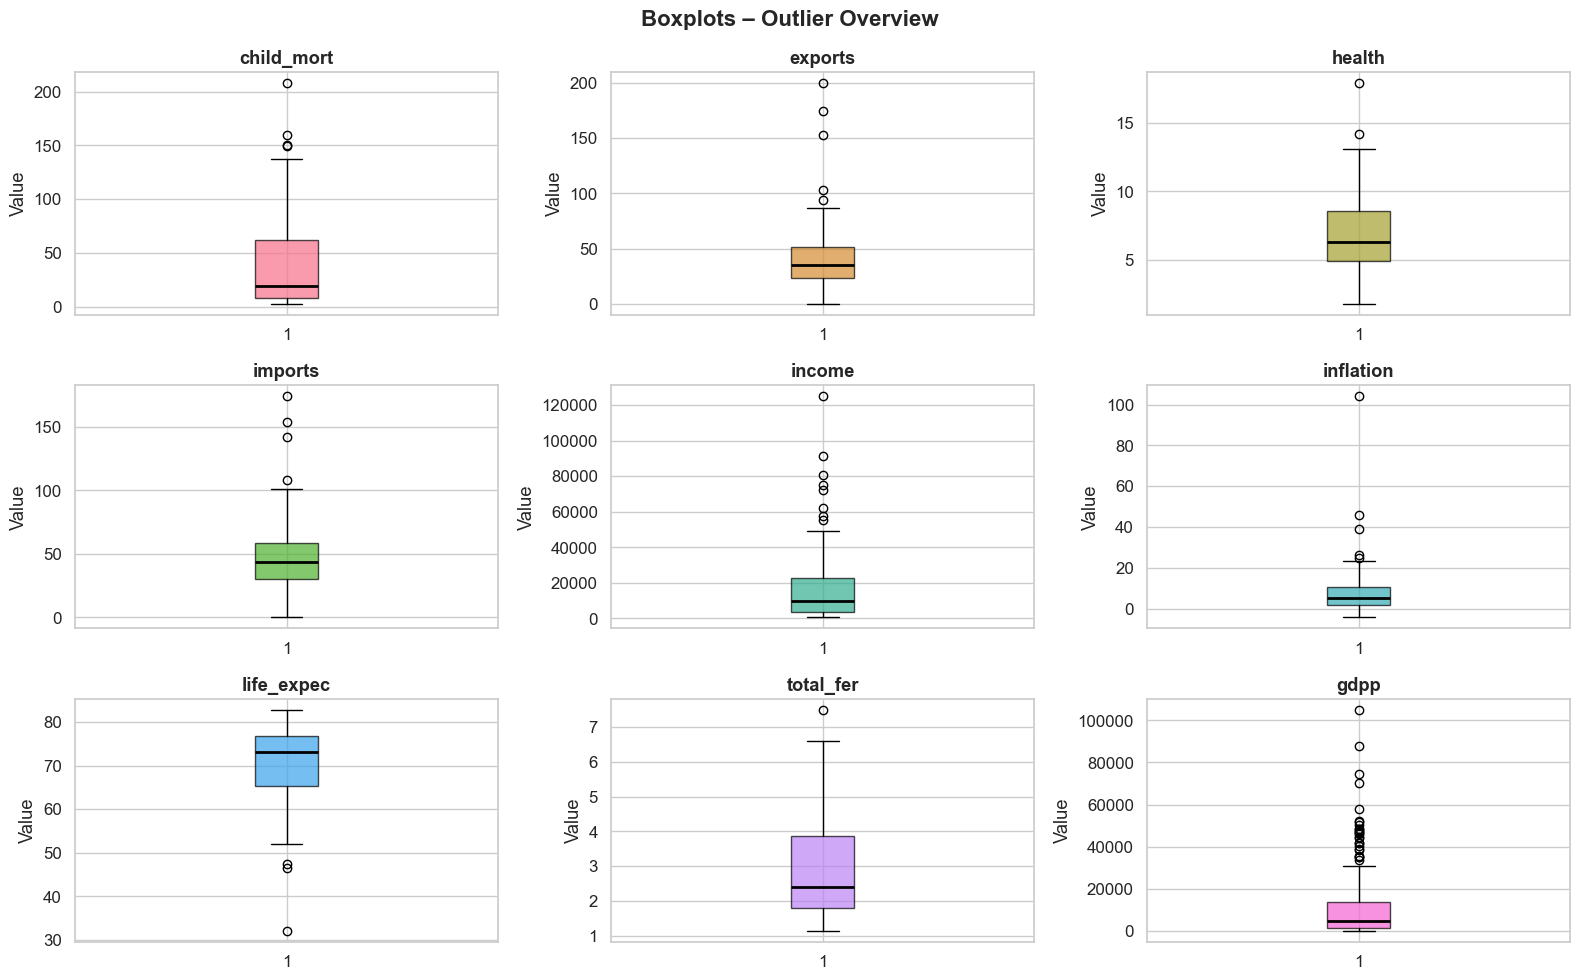

In [7]:
# ── 3.4 Boxplots – Outlier Detection ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots – Outlier Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

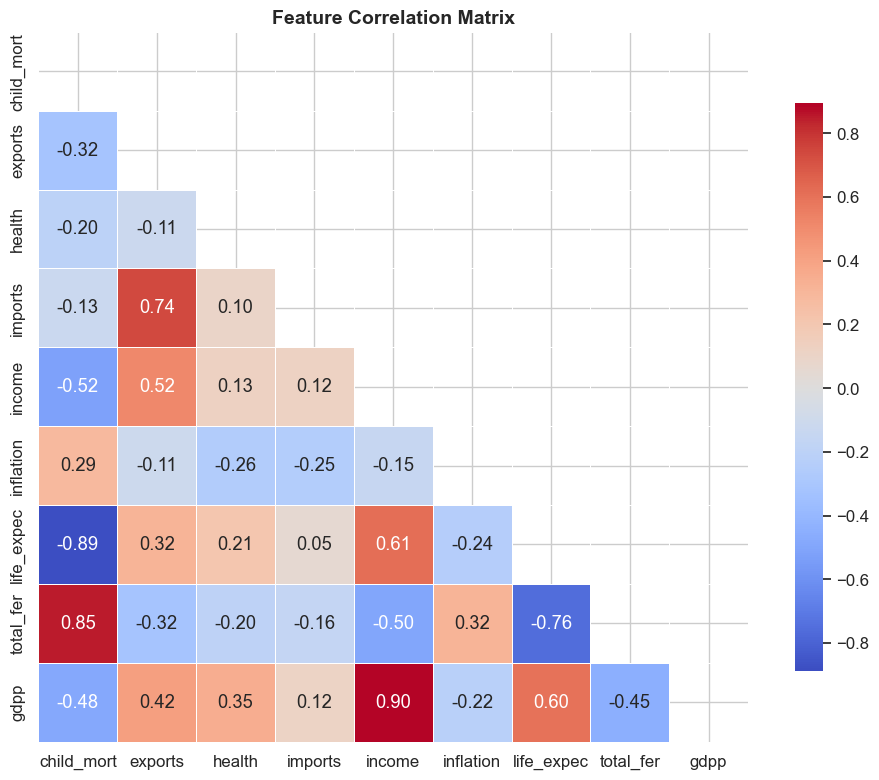


🔍 Key correlations:
  • child_mort ↔ life_expec : strong negative (healthier = longer life)
  • income     ↔ gdpp       : strong positive (income drives GDP/cap)
  • child_mort ↔ total_fer  : strong positive (high fertility in poor countries)
  • health     ↔ life_expec : moderate positive


In [8]:
# ── 3.5 Correlation Heatmap ───────────────────────────────────────────────
corr = df_raw[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Key correlations:')
print('  • child_mort ↔ life_expec : strong negative (healthier = longer life)')
print('  • income     ↔ gdpp       : strong positive (income drives GDP/cap)')
print('  • child_mort ↔ total_fer  : strong positive (high fertility in poor countries)')
print('  • health     ↔ life_expec : moderate positive')

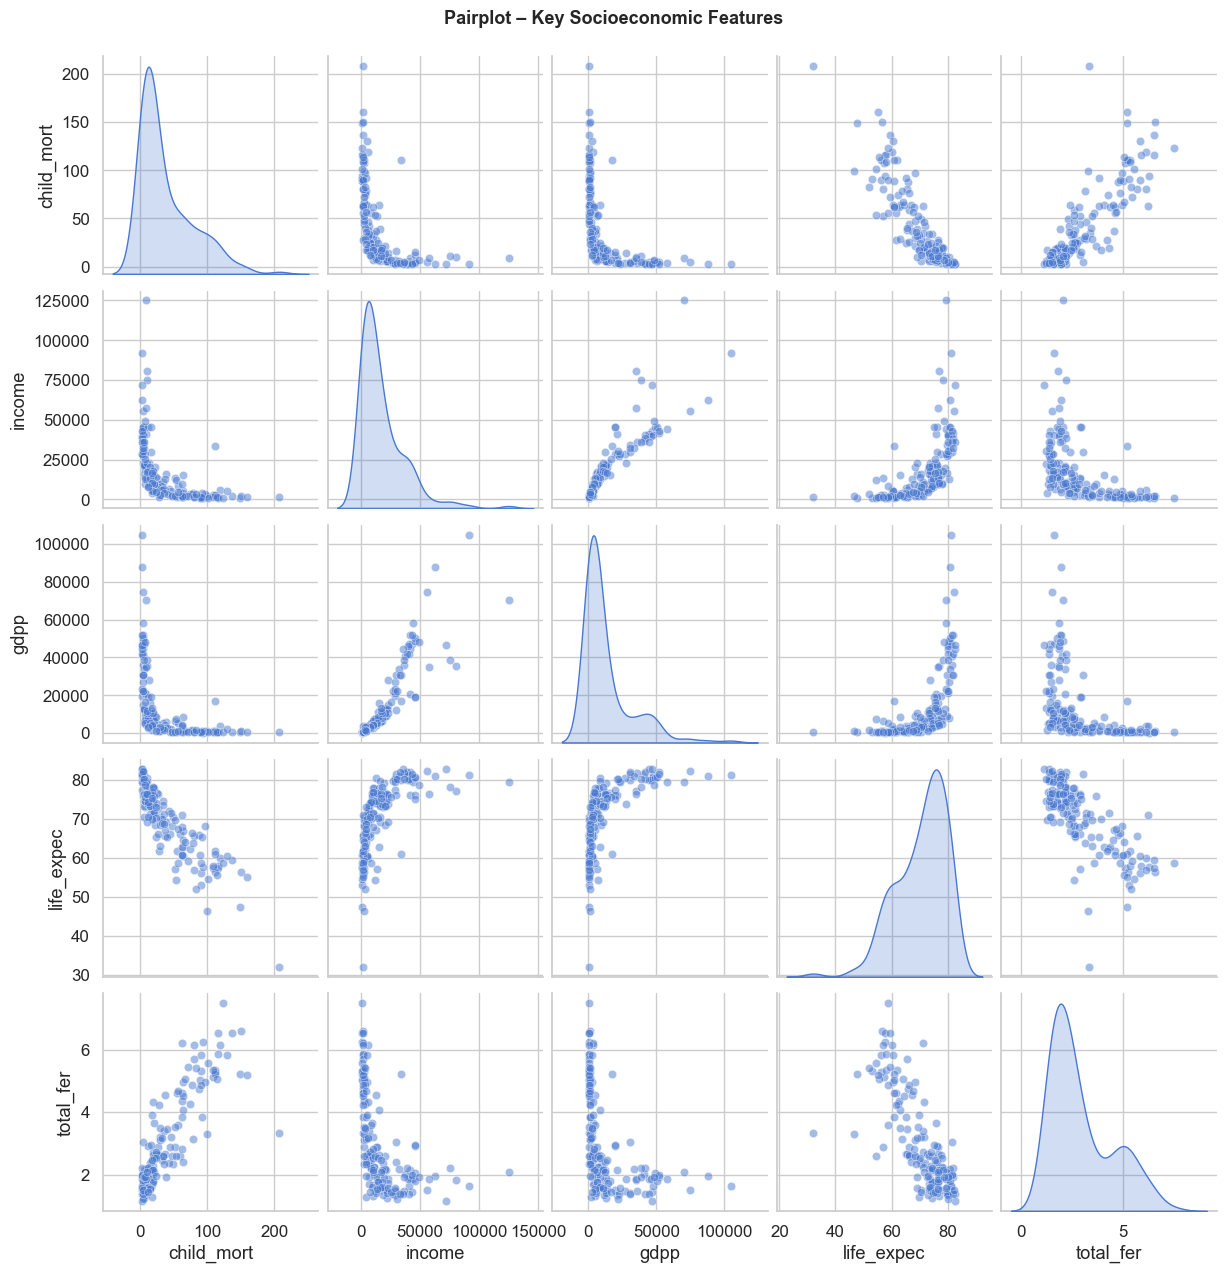

In [9]:
# ── 3.6 Pairplot – Key Features ───────────────────────────────────────────
key_feats = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']
sns.pairplot(df_raw[key_feats], diag_kind='kde', plot_kws={'alpha': 0.5},
             diag_kws={'fill': True})
plt.suptitle('Pairplot – Key Socioeconomic Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

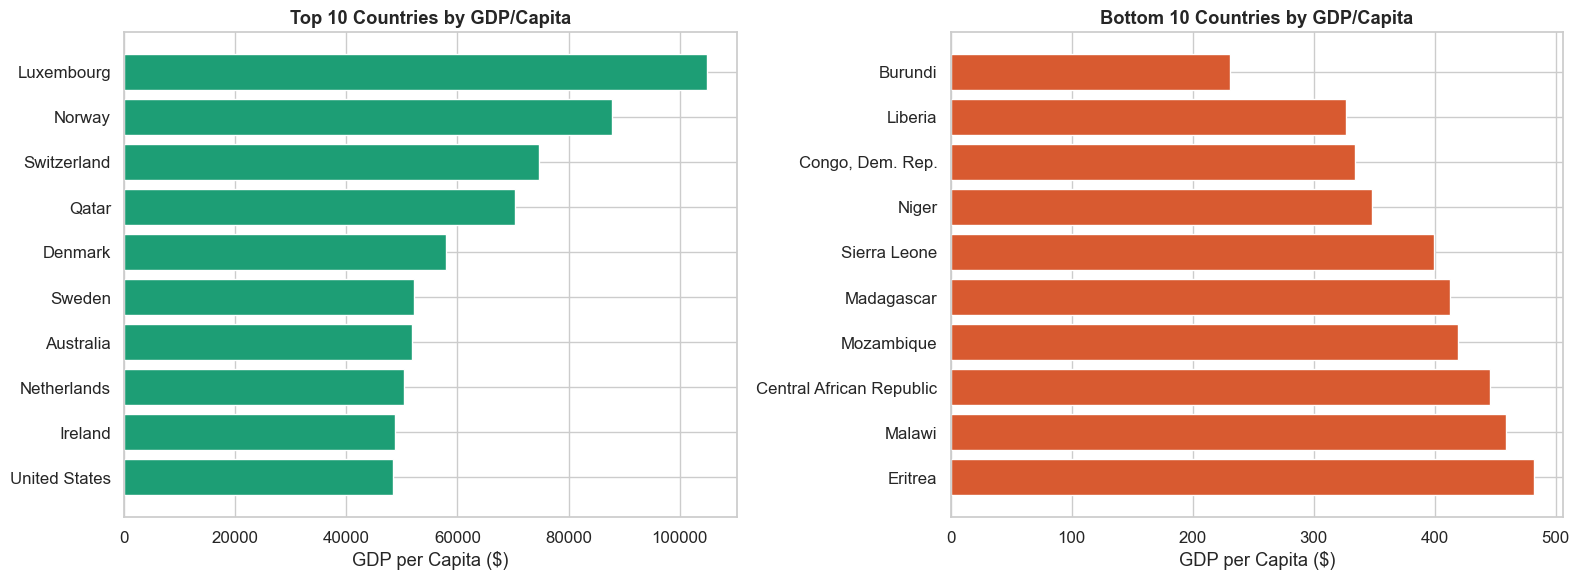

In [10]:
# ── 3.7 Top / Bottom Countries by GDP per Capita ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = df_raw.nlargest(10, 'gdpp')
bot10 = df_raw.nsmallest(10, 'gdpp')

axes[0].barh(top10['country'], top10['gdpp'], color='#1D9E75', edgecolor='white')
axes[0].set_title('Top 10 Countries by GDP/Capita', fontweight='bold')
axes[0].set_xlabel('GDP per Capita ($)')
axes[0].invert_yaxis()

axes[1].barh(bot10['country'], bot10['gdpp'], color='#D85A30', edgecolor='white')
axes[1].set_title('Bottom 10 Countries by GDP/Capita', fontweight='bold')
axes[1].set_xlabel('GDP per Capita ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

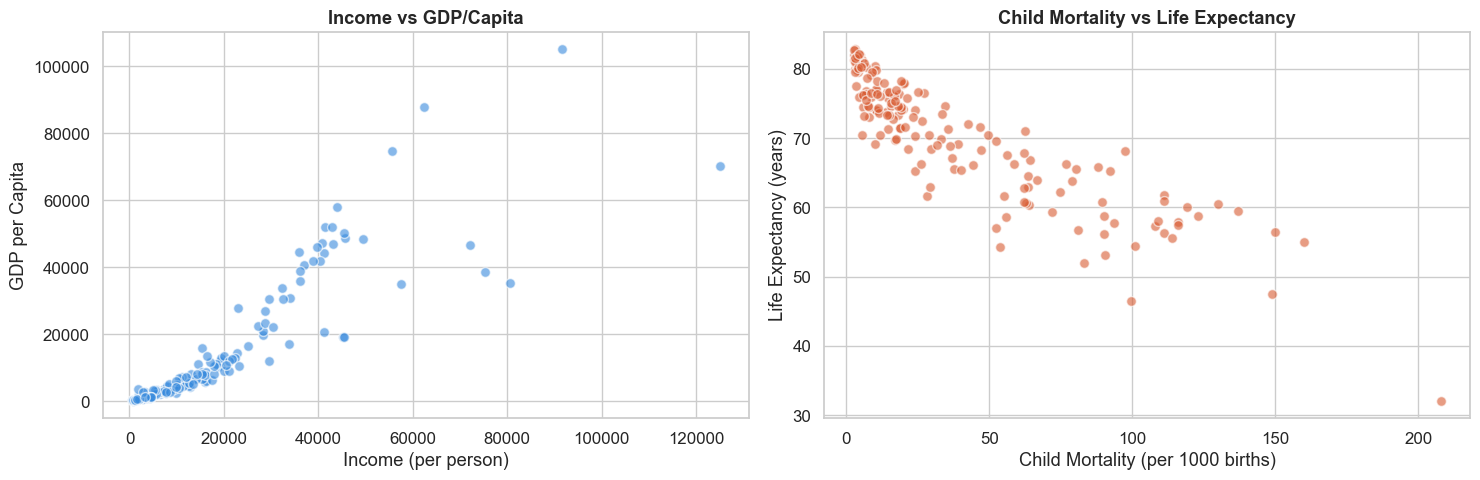

In [11]:
# ── 3.8 Income vs GDP/Capita Scatter ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(df_raw['income'], df_raw['gdpp'], alpha=0.6, color='#378ADD', edgecolors='white', s=50)
axes[0].set_xlabel('Income (per person)')
axes[0].set_ylabel('GDP per Capita')
axes[0].set_title('Income vs GDP/Capita', fontweight='bold')

axes[1].scatter(df_raw['child_mort'], df_raw['life_expec'], alpha=0.6, color='#D85A30', edgecolors='white', s=50)
axes[1].set_xlabel('Child Mortality (per 1000 births)')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('Child Mortality vs Life Expectancy', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [12]:
# ── 4.1 Clean & Prepare ───────────────────────────────────────────────────
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
missing_before = df[numeric_cols].isnull().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(f'Missing values before fill : {missing_before}')
print(f'Missing values after fill  : {df[numeric_cols].isnull().sum().sum()}')
print(f'Final dataset shape        : {df.shape}')

Missing values before fill : 0
Missing values after fill  : 0
Final dataset shape        : (167, 10)


In [13]:
# ── 4.2 Feature Engineering ───────────────────────────────────────────────
df['trade_balance']   = df['exports'] - df['imports']   # net trade
df['health_per_gdpp'] = df['health']  / (df['gdpp'] + 1)  # health spending efficiency
df['development_idx'] = (df['life_expec'] / df['life_expec'].max()
                         + (1 - df['child_mort'] / df['child_mort'].max())
                         + df['income']  / df['income'].max()) / 3

print('✅ Engineered features added:')
print('  • trade_balance   = exports − imports')
print('  • health_per_gdpp = health / gdpp')
print('  • development_idx = composite (life_expec + child_mort + income)')
df[['country','trade_balance','health_per_gdpp','development_idx']].head()

✅ Engineered features added:
  • trade_balance   = exports − imports
  • health_per_gdpp = health / gdpp
  • development_idx = composite (life_expec + child_mort + income)


,country,trade_balance,health_per_gdpp,development_idx
0,Afghanistan,-34.9,0.013682,0.419323
1,Albania,-20.6,0.001601,0.640377
2,Algeria,7.0,0.000935,0.631954
3,Angola,19.4,0.000807,0.400310
4,Antigua and Barbuda,-13.4,0.000494,0.676939


In [14]:
# ── 4.3 Scale Features ────────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'country']
features     = df[feature_cols].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f'Scaled feature matrix shape : {X_scaled.shape}')
print(f'Mean ≈ 0 : {np.abs(X_scaled.mean(axis=0)).mean():.4f}')
print(f'Std  ≈ 1 : {X_scaled.std(axis=0).mean():.4f}')

Scaled feature matrix shape : (167, 12)
Mean ≈ 0 : 0.0000
Std  ≈ 1 : 1.0000


## 5. Clustering – Unsupervised Segmentation

### 5.1 K-Means – Elbow Method & Silhouette Analysis

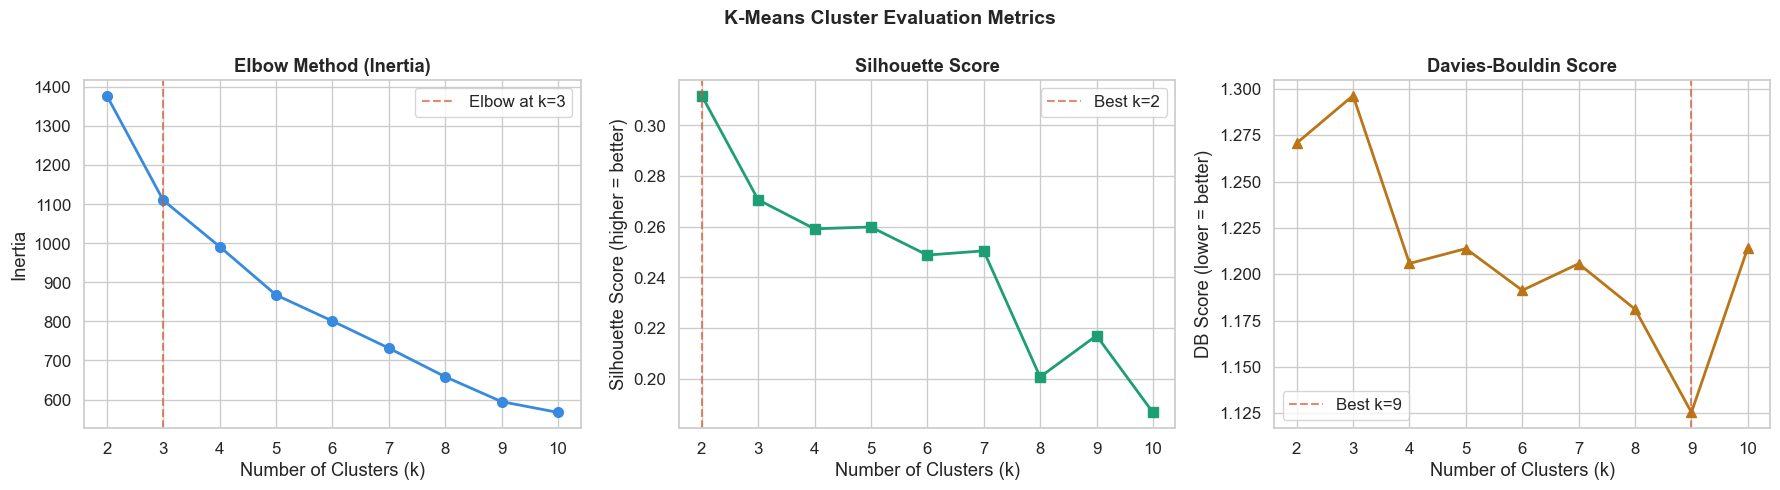


📊 Best k by Silhouette  : 2 (score = 0.3118)
📊 Best k by Davies-Bouldin: 9
📊 Chosen k              : 3  (balances interpretability + metrics)


In [15]:
k_range = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(k_range), inertias, 'o-', color='#378ADD', linewidth=2, markersize=7)
axes[0].axvline(x=3, color='#D85A30', linestyle='--', alpha=0.7, label='Elbow at k=3')
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, 's-', color='#1D9E75', linewidth=2, markersize=7)
best_k_sil = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k_sil, color='#D85A30', linestyle='--', alpha=0.7, label=f'Best k={best_k_sil}')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].legend()

axes[2].plot(list(k_range), db_scores, '^-', color='#BA7517', linewidth=2, markersize=7)
best_k_db = list(k_range)[np.argmin(db_scores)]
axes[2].axvline(x=best_k_db, color='#D85A30', linestyle='--', alpha=0.7, label=f'Best k={best_k_db}')
axes[2].set_title('Davies-Bouldin Score', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('DB Score (lower = better)')
axes[2].legend()

plt.suptitle('K-Means Cluster Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📊 Best k by Silhouette  : {best_k_sil} (score = {max(sil_scores):.4f})')
print(f'📊 Best k by Davies-Bouldin: {best_k_db}')
print(f'📊 Chosen k              : 3  (balances interpretability + metrics)')

### 5.2 Train Final K-Means (k=3)

In [16]:
BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=15, max_iter=500)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil  = silhouette_score(X_scaled, df['kmeans_cluster'])
db   = davies_bouldin_score(X_scaled, df['kmeans_cluster'])

print(f'K-Means (k={BEST_K}) Results')
print(f'  Silhouette Score    : {sil:.4f}  (closer to 1 = better separation)')
print(f'  Davies-Bouldin Score: {db:.4f}  (lower = better compactness)')
print()
print('Cluster distribution:')
print(df['kmeans_cluster'].value_counts().sort_index())

K-Means (k=3) Results
  Silhouette Score    : 0.2688  (closer to 1 = better separation)
  Davies-Bouldin Score: 1.2992  (lower = better compactness)

Cluster distribution:
kmeans_cluster
0    85
1    38
2    44
Name: count, dtype: int64


### 5.3 PCA Visualization of K-Means Clusters

PC1 explained variance : 47.32%
PC2 explained variance : 14.81%
Total (2 PCs)          : 62.13%


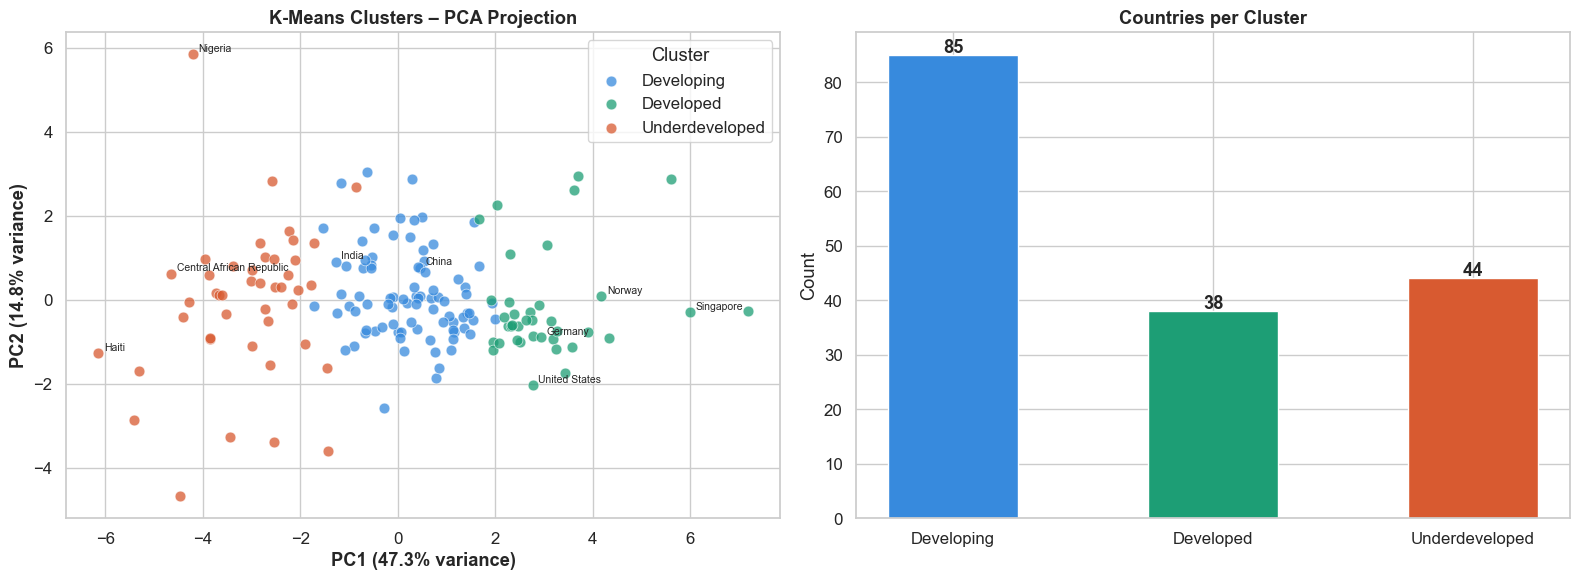

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

var_exp = pca.explained_variance_ratio_
print(f'PC1 explained variance : {var_exp[0]*100:.2f}%')
print(f'PC2 explained variance : {var_exp[1]*100:.2f}%')
print(f'Total (2 PCs)          : {sum(var_exp)*100:.2f}%')

CLUSTER_COLORS = ['#378ADD', '#1D9E75', '#D85A30']
CLUSTER_LABELS = {0: 'Developing', 1: 'Developed', 2: 'Underdeveloped'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for ci in range(BEST_K):
    mask = df['kmeans_cluster'] == ci
    axes[0].scatter(df.loc[mask, 'pca1'], df.loc[mask, 'pca2'],
                    c=CLUSTER_COLORS[ci], label=CLUSTER_LABELS[ci],
                    alpha=0.75, s=60, edgecolors='white', linewidth=0.5)

# Annotate a few notable countries
notable = ['United States', 'Norway', 'Singapore', 'Nigeria', 'Haiti',
           'Central African Republic', 'China', 'India', 'Germany']
for _, row in df[df['country'].isin(notable)].iterrows():
    axes[0].annotate(row['country'], (row['pca1'], row['pca2']),
                     fontsize=7.5, ha='left',
                     xytext=(4, 2), textcoords='offset points')

axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)', fontweight='bold')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)', fontweight='bold')
axes[0].set_title('K-Means Clusters – PCA Projection', fontweight='bold')
axes[0].legend(title='Cluster')

# Cluster counts bar chart
counts = df['kmeans_cluster'].value_counts().sort_index()
axes[1].bar([CLUSTER_LABELS[i] for i in counts.index], counts.values,
            color=CLUSTER_COLORS[:BEST_K], edgecolor='white', width=0.5)
axes[1].set_title('Countries per Cluster', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 Cluster Profiling

In [18]:
orig_numeric = [c for c in numeric_cols if c in df.columns]
profile = df.groupby('kmeans_cluster')[orig_numeric].mean().round(2)
profile.index = [CLUSTER_LABELS[i] for i in profile.index]
print('=== Cluster Mean Feature Profiles ===')
profile.style.background_gradient(cmap='RdYlGn', axis=0)

=== Cluster Mean Feature Profiles ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Developing,23.770000,40.940000,6.160000,46.350000,11797.530000,7.710000,72.110000,2.350000,6308.050000
Developed,5.460000,58.680000,8.530000,50.730000,45655.260000,3.390000,79.890000,1.810000,41273.680000
Underdeveloped,94.610000,26.260000,6.600000,44.610000,2851.660000,11.710000,59.500000,5.090000,1373.410000


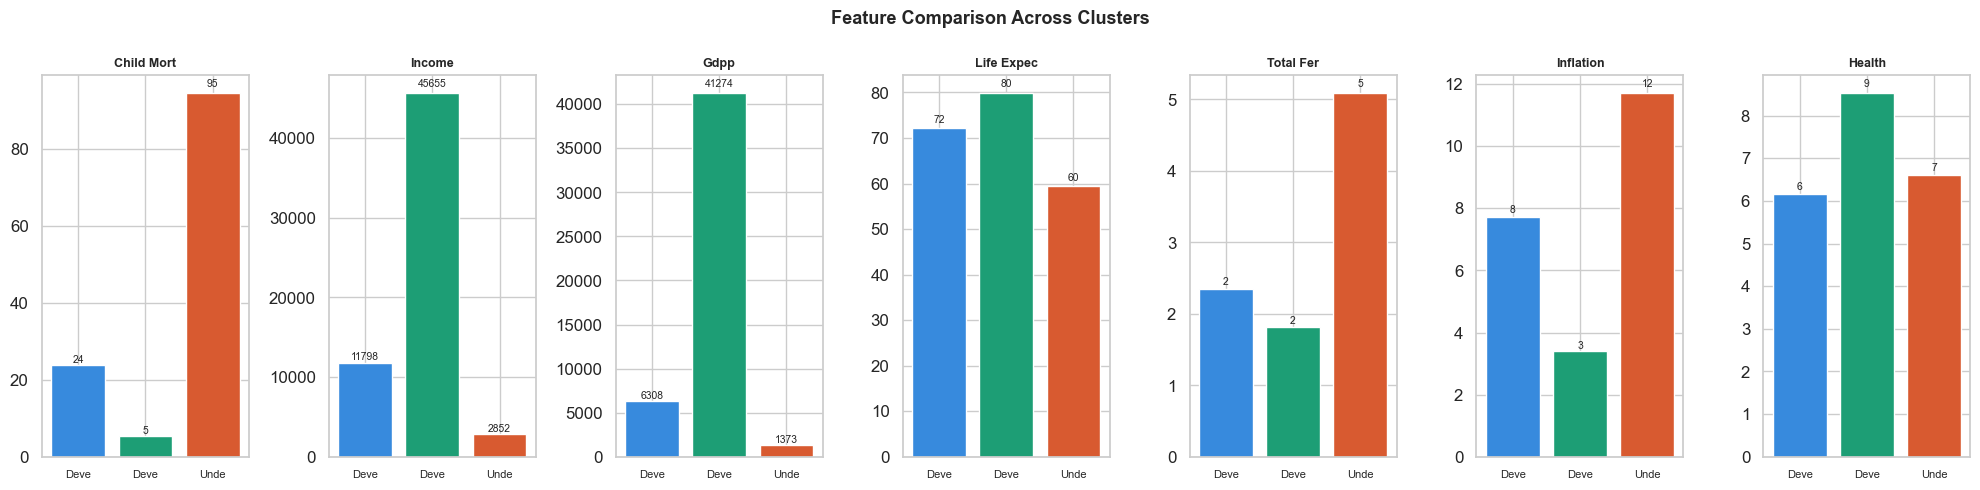

In [19]:
# Radar / Bar comparison across clusters
plot_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation', 'health']
n_feats = len(plot_features)

fig, axes = plt.subplots(1, n_feats, figsize=(20, 5))

for ax, feat in zip(axes, plot_features):
    vals = [profile.loc[CLUSTER_LABELS[i], feat] for i in range(BEST_K)]
    bars = ax.bar([CLUSTER_LABELS[i] for i in range(BEST_K)], vals,
                  color=CLUSTER_COLORS[:BEST_K], edgecolor='white')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold', fontsize=9)
    ax.set_xticks(range(BEST_K))
    ax.set_xticklabels([CLUSTER_LABELS[i][:4] for i in range(BEST_K)], fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.0f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Feature Comparison Across Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Top 5 countries per cluster
print('=== Top countries per cluster (by GDP/cap) ===')
for ci in range(BEST_K):
    subset = df[df['kmeans_cluster'] == ci].nlargest(5, 'gdpp')
    print(f'\n{CLUSTER_LABELS[ci]} (Cluster {ci}):')
    print(subset[['country','gdpp','income','life_expec','child_mort']].to_string(index=False))

=== Top countries per cluster (by GDP/cap) ===

Developing (Cluster 0):
  country  gdpp  income  life_expec  child_mort
  Bahamas 28000   22900        73.8        13.8
 Barbados 16000   15300        76.7        14.2
  Estonia 14600   22700        76.0         4.5
  Croatia 13500   20100        76.3         5.5
Venezuela 13500   16500        75.4        17.1

Developed (Cluster 1):
    country   gdpp  income  life_expec  child_mort
 Luxembourg 105000   91700        81.3         2.8
     Norway  87800   62300        81.0         3.2
Switzerland  74600   55500        82.2         4.5
      Qatar  70300  125000        79.5         9.0
    Denmark  58000   44000        79.5         4.1

Underdeveloped (Cluster 2):
              country  gdpp  income  life_expec  child_mort
    Equatorial Guinea 17100   33700        60.9       111.0
          Timor-Leste  3600    1850        71.1        62.6
               Angola  3530    5900        60.1       119.0
Micronesia, Fed. Sts.  2860    3340      

### 5.5 DBSCAN Clustering

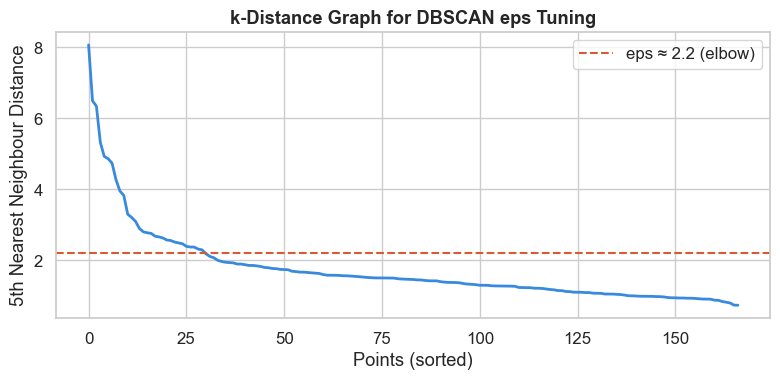

In [21]:
# ── Tune eps using k-distance graph ───────────────────────────────────────
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color='#378ADD', linewidth=2)
plt.axhline(y=2.2, color='#D85A30', linestyle='--', label='eps ≈ 2.2 (elbow)')
plt.title('k-Distance Graph for DBSCAN eps Tuning', fontweight='bold')
plt.xlabel('Points (sorted)')
plt.ylabel('5th Nearest Neighbour Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
dbscan = DBSCAN(eps=2.2, min_samples=4)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db  = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise        = (df['dbscan_cluster'] == -1).sum()

print(f'DBSCAN Results')
print(f'  Clusters found : {n_clusters_db}')
print(f'  Noise points   : {n_noise} ({n_noise/len(df)*100:.1f}%)')
print()
print('Cluster distribution:')
print(df['dbscan_cluster'].value_counts().sort_index())

DBSCAN Results
  Clusters found : 1
  Noise points   : 23 (13.8%)

Cluster distribution:
dbscan_cluster
-1     23
 0    144
Name: count, dtype: int64


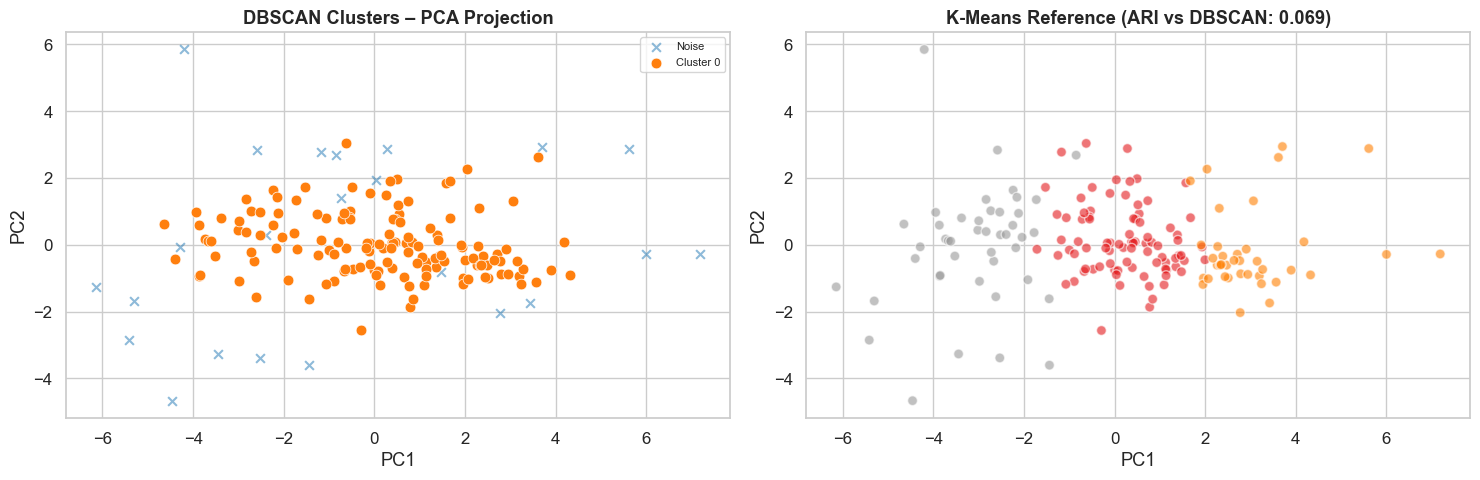


Adjusted Rand Index (KMeans vs DBSCAN) = 0.0693
Note: DBSCAN is sensitive to outliers (noise) – noise points show countries
      with unusual combinations of features (e.g., Qatar, Luxembourg, Singapore).


In [23]:
# ── DBSCAN PCA Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
unique_db = sorted(df['dbscan_cluster'].unique())
db_palette = sns.color_palette('tab10', len(unique_db))

for ci, color in zip(unique_db, db_palette):
    mask  = df['dbscan_cluster'] == ci
    label = f'Noise' if ci == -1 else f'Cluster {ci}'
    style = dict(marker='x', s=40, alpha=0.5) if ci == -1 else dict(s=60, edgecolors='white', linewidth=0.5)
    axes[0].scatter(df.loc[mask,'pca1'], df.loc[mask,'pca2'],
                    c=[color], label=label, **style)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('DBSCAN Clusters – PCA Projection', fontweight='bold')
axes[0].legend(fontsize=8)

# Comparison: KMeans vs DBSCAN
ari = adjusted_rand_score(df['kmeans_cluster'], df['dbscan_cluster'])
axes[1].scatter(df['pca1'], df['pca2'], c=df['kmeans_cluster'],
                cmap='Set1', alpha=0.6, s=50, edgecolors='white')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'K-Means Reference (ARI vs DBSCAN: {ari:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nAdjusted Rand Index (KMeans vs DBSCAN) = {ari:.4f}')
print('Note: DBSCAN is sensitive to outliers (noise) – noise points show countries')
print('      with unusual combinations of features (e.g., Qatar, Luxembourg, Singapore).')

## 6. Classification – Predicting Cluster Labels

> We use the **K-Means cluster labels** as the target variable (y) and train supervised models to learn the segmentation decision boundary — enabling prediction for new/unseen countries.

In [24]:
# ── Prepare X, y ──────────────────────────────────────────────────────────
clf_features = [c for c in df.columns
                if c not in ['country','kmeans_cluster','dbscan_cluster','pca1','pca2']]

X = df[clf_features].values
y = df['kmeans_cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Re-scale after split to prevent data leakage
scaler2   = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s  = scaler2.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features used    : {len(clf_features)}')
print(f'Class balance    :')
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'   Cluster {cls} ({CLUSTER_LABELS[cls]}): {cnt} samples')

Training samples : 133
Test samples     : 34
Features used    : 12
Class balance    :
   Cluster 0 (Developing): 68 samples
   Cluster 1 (Developed): 30 samples
   Cluster 2 (Underdeveloped): 35 samples


### 6.1 Baseline Models

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6),
    'SVM (RBF kernel)'    : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

results = {}
for name, model in baseline_models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_s, y_train)
    test_acc  = accuracy_score(y_test, model.predict(X_test_s))
    results[name] = {'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std(), 'Test Acc': test_acc}
    print(f'{name:25s} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}')

print('\n✅ Baseline models trained.')

Logistic Regression       | CV: 0.9778 ± 0.0296 | Test: 0.9706
K-Nearest Neighbours      | CV: 0.9476 ± 0.0301 | Test: 0.9412
Decision Tree             | CV: 0.9254 ± 0.0325 | Test: 0.9412
SVM (RBF kernel)          | CV: 0.9328 ± 0.0271 | Test: 0.9706

✅ Baseline models trained.


### 6.2 Ensemble Models – Random Forest & XGBoost

In [26]:
ensemble_models = {
    'Random Forest'           : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                        min_samples_leaf=2, random_state=RANDOM_STATE),
    'Gradient Boosting'       : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                             max_depth=4, random_state=RANDOM_STATE),
    'XGBoost'                 : XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                               use_label_encoder=False, eval_metric='mlogloss',
                                               random_state=RANDOM_STATE, verbosity=0),
    'AdaBoost'                : AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Bagging (DT)'            : BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                                                   n_estimators=100, random_state=RANDOM_STATE),
}

for name, model in ensemble_models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_s, y_train)
    test_acc  = accuracy_score(y_test, model.predict(X_test_s))
    results[name] = {'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std(), 'Test Acc': test_acc}
    print(f'{name:25s} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}')

print('\n✅ Ensemble models trained.')

Random Forest             | CV: 0.9627 ± 0.0234 | Test: 0.9706
Gradient Boosting         | CV: 0.9479 ± 0.0295 | Test: 0.9412
XGBoost                   | CV: 0.9553 ± 0.0362 | Test: 1.0000
AdaBoost                  | CV: 0.9245 ± 0.0248 | Test: 0.9412
Bagging (DT)              | CV: 0.9553 ± 0.0276 | Test: 0.9412

✅ Ensemble models trained.


### 6.3 Model Comparison

In [27]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('Test Acc', ascending=False)
print('=== Model Leaderboard ===')
results_df.style.background_gradient(cmap='Greens', subset=['CV Mean','Test Acc'])

=== Model Leaderboard ===


,CV Mean,CV Std,Test Acc
XGBoost,0.955300,0.036200,1.000000
Logistic Regression,0.977800,0.029600,0.970600
SVM (RBF kernel),0.932800,0.027100,0.970600
Random Forest,0.962700,0.023400,0.970600
K-Nearest Neighbours,0.947600,0.030100,0.941200
Decision Tree,0.925400,0.032500,0.941200
Gradient Boosting,0.947900,0.029500,0.941200
AdaBoost,0.924500,0.024800,0.941200
Bagging (DT),0.955300,0.027600,0.941200


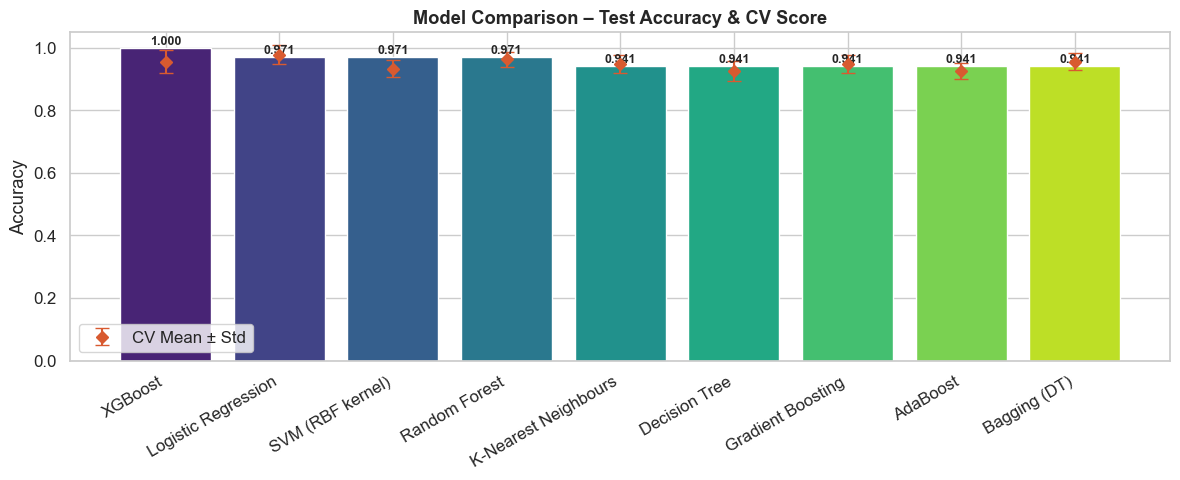

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(results_df))

bars = ax.bar(x, results_df['Test Acc'], color=sns.color_palette('viridis', len(results_df)),
              edgecolor='white', zorder=2)
ax.errorbar(x, results_df['CV Mean'], yerr=results_df['CV Std'],
            fmt='D', color='#D85A30', markersize=6, capsize=5,
            label='CV Mean ± Std', zorder=3)

ax.set_xticks(list(x))
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison – Test Accuracy & CV Score', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)

for bar, acc in zip(bars, results_df['Test Acc']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{acc:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Best Model – Deep Dive

In [29]:
best_name  = results_df.index[0]
all_models = {**baseline_models, **ensemble_models}
best_model = all_models[best_name]

y_pred = best_model.predict(X_test_s)
print(f'🏆 Best Model : {best_name}')
print(f'   Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print()
print('=== Classification Report ===')
target_names = [CLUSTER_LABELS[i] for i in sorted(np.unique(y))]
print(classification_report(y_test, y_pred, target_names=target_names))

🏆 Best Model : XGBoost
   Test Accuracy : 1.0000

=== Classification Report ===
                precision    recall  f1-score   support

    Developing       1.00      1.00      1.00        17
     Developed       1.00      1.00      1.00         8
Underdeveloped       1.00      1.00      1.00         9

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



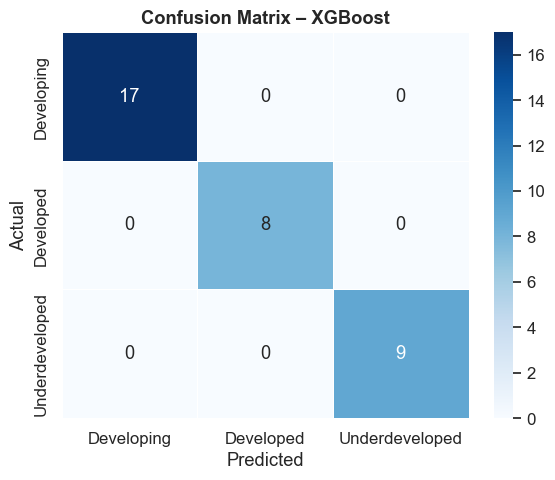

In [30]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix – {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

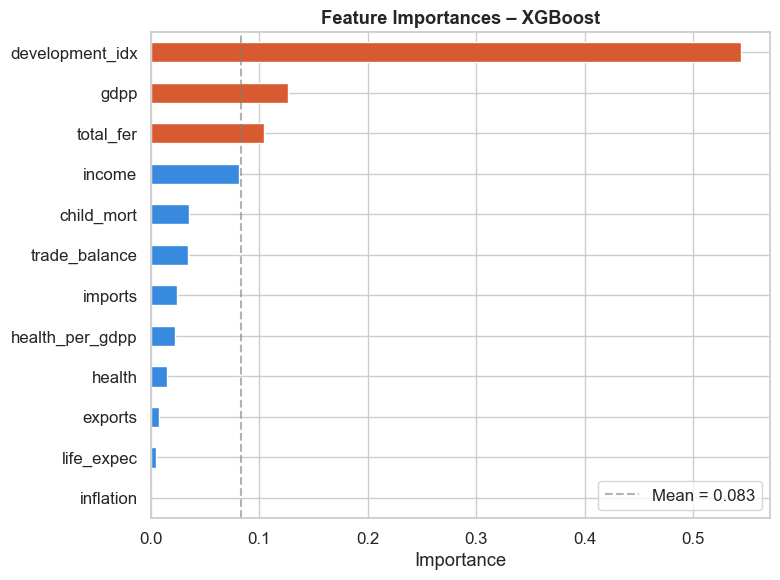


Top 5 most important features:
development_idx    0.544209
gdpp               0.126520
total_fer          0.104748
income             0.080949
child_mort         0.035433
dtype: float32


In [31]:
# ── Feature Importance (if tree-based) ────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=clf_features).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors_fi = ['#D85A30' if v >= fi.quantile(0.75) else '#378ADD' for v in fi]
    fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
    ax.set_title(f'Feature Importances – {best_name}', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.axvline(x=fi.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Mean = {fi.mean():.3f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('\nTop 5 most important features:')
    print(fi.sort_values(ascending=False).head(5))

## 8. Voting Ensemble – Combining Top Models

In [32]:
rf_final  = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
xgb_final = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                           use_label_encoder=False, eval_metric='mlogloss',
                           random_state=RANDOM_STATE, verbosity=0)
gb_final  = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                        max_depth=4, random_state=RANDOM_STATE)

voting_clf = VotingClassifier(
    estimators=[
        ('rf',  rf_final),
        ('xgb', xgb_final),
        ('gb',  gb_final),
    ],
    voting='soft'
)

voting_clf.fit(X_train_s, y_train)
y_pred_v  = voting_clf.predict(X_test_s)
acc_vote  = accuracy_score(y_test, y_pred_v)

cv_vote   = cross_val_score(voting_clf, X_train_s, y_train, cv=cv, scoring='accuracy')

print('=== Soft Voting Ensemble (RF + XGBoost + GradientBoosting) ===')
print(f'  CV Accuracy  : {cv_vote.mean():.4f} ± {cv_vote.std():.4f}')
print(f'  Test Accuracy: {acc_vote:.4f}')
print()
print(classification_report(y_test, y_pred_v, target_names=target_names))

=== Soft Voting Ensemble (RF + XGBoost + GradientBoosting) ===
  CV Accuracy  : 0.9479 ± 0.0377
  Test Accuracy: 0.9412

                precision    recall  f1-score   support

    Developing       0.94      0.94      0.94        17
     Developed       1.00      1.00      1.00         8
Underdeveloped       0.89      0.89      0.89         9

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34



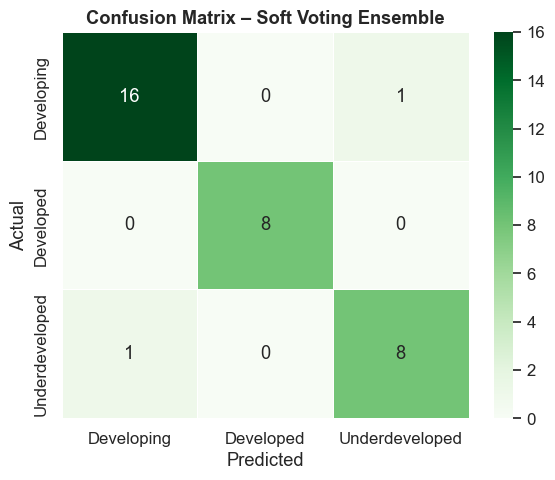

In [33]:
# ── Confusion Matrix – Voting Ensemble ────────────────────────────────────
cm_v = confusion_matrix(y_test, y_pred_v)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_v, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix – Soft Voting Ensemble', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning – XGBoost (GridSearchCV)

In [34]:
param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0],
}

xgb_gs = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                        random_state=RANDOM_STATE, verbosity=0)

gs = GridSearchCV(xgb_gs, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0)
gs.fit(X_train_s, y_train)

print(f'Best XGBoost params : {gs.best_params_}')
print(f'Best CV accuracy    : {gs.best_score_:.4f}')
print(f'Test accuracy       : {accuracy_score(y_test, gs.predict(X_test_s)):.4f}')

Best XGBoost params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV accuracy    : 0.9553
Test accuracy       : 0.9706


## 10. Final Insights & Recommendations

In [35]:
# ── 10.1 Cluster Summary Statistics ───────────────────────────────────────
insight_cols = ['child_mort', 'income', 'gdpp', 'life_expec', 'inflation', 'health', 'total_fer']
summary = df.groupby('kmeans_cluster')[insight_cols].agg(['mean','median']).round(2)
summary.index = [CLUSTER_LABELS[i] for i in summary.index]
print('=== Final Cluster Summary ===')
print(summary.to_string())

=== Final Cluster Summary ===
               child_mort           income               gdpp          life_expec        inflation        health        total_fer       
                     mean median      mean   median      mean   median       mean median      mean median   mean median      mean median
Developing          23.77  18.90  11797.53  10500.0   6308.05   5020.0      72.11   73.4      7.71   5.88   6.16   6.00      2.35   2.24
Developed            5.46   4.25  45655.26  40900.0  41273.68  39750.0      79.89   80.3      3.39   1.40   8.53   9.41      1.81   1.85
Underdeveloped      94.61  90.40   2851.66   1800.0   1373.41    748.0      59.50   60.3     11.71   8.22   6.60   5.68      5.09   5.16


In [36]:
# ── 10.2 Countries Requiring Aid (Underdeveloped cluster) ──────────────────
underdeveloped_cluster = df.groupby('kmeans_cluster')['child_mort'].mean().idxmax()
aid_countries = (df[df['kmeans_cluster'] == underdeveloped_cluster]
                 .sort_values('gdpp')[['country','child_mort','income','gdpp','life_expec']]
                 .head(15))

print(f'=== Top Countries Requiring International Aid ===')
print(f'    (Cluster: {CLUSTER_LABELS[underdeveloped_cluster]})')
print(aid_countries.to_string(index=False))

=== Top Countries Requiring International Aid ===
    (Cluster: Underdeveloped)
                 country  child_mort  income  gdpp  life_expec
                 Burundi        93.6     764   231        57.7
                 Liberia        89.3     700   327        60.8
        Congo, Dem. Rep.       116.0     609   334        57.5
                   Niger       123.0     814   348        58.8
            Sierra Leone       160.0    1220   399        55.0
              Madagascar        62.2    1390   413        60.8
              Mozambique       101.0     918   419        54.5
Central African Republic       149.0     888   446        47.5
                  Malawi        90.5    1030   459        53.1
                 Eritrea        55.2    1420   482        61.7
                    Togo        90.3    1210   488        58.7
           Guinea-Bissau       114.0    1390   547        55.6
             Afghanistan        90.2    1610   553        56.2
                  Gambia        80.3  

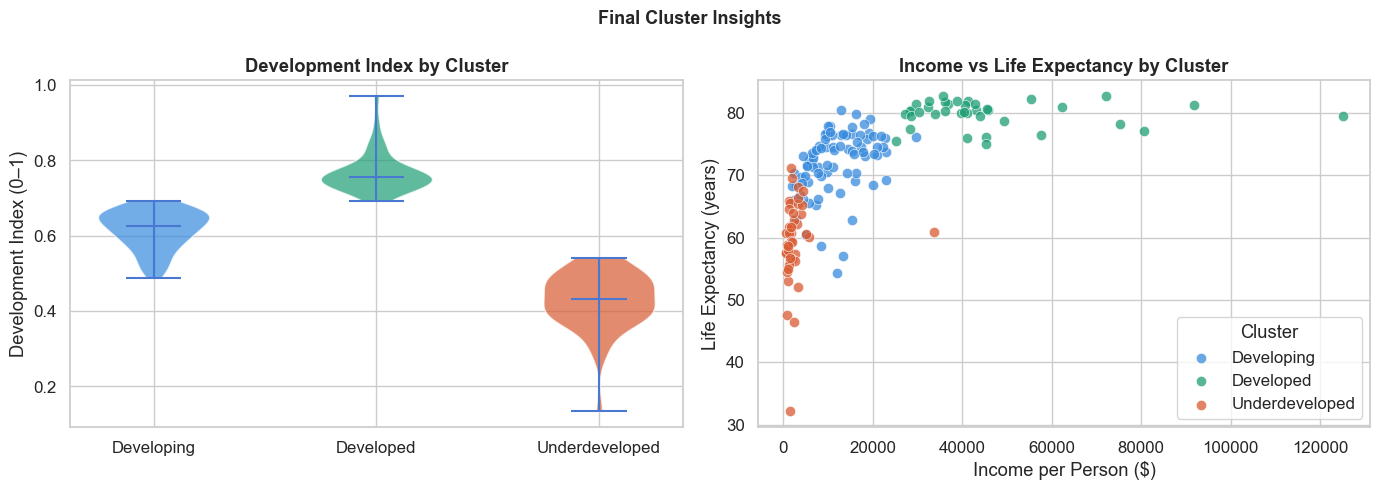

In [37]:
# ── 10.3 Development Index Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot – development index
data_violin = [df[df['kmeans_cluster']==ci]['development_idx'].values for ci in range(BEST_K)]
vp = axes[0].violinplot(data_violin, positions=range(BEST_K), showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(CLUSTER_COLORS[i])
    pc.set_alpha(0.7)
axes[0].set_xticks(range(BEST_K))
axes[0].set_xticklabels([CLUSTER_LABELS[i] for i in range(BEST_K)])
axes[0].set_title('Development Index by Cluster', fontweight='bold')
axes[0].set_ylabel('Development Index (0–1)')

# Scatter – income vs life expectancy, coloured by cluster
for ci in range(BEST_K):
    mask = df['kmeans_cluster'] == ci
    axes[1].scatter(df.loc[mask,'income'], df.loc[mask,'life_expec'],
                    c=CLUSTER_COLORS[ci], label=CLUSTER_LABELS[ci],
                    alpha=0.75, s=55, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Income per Person ($)')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('Income vs Life Expectancy by Cluster', fontweight='bold')
axes[1].legend(title='Cluster')

plt.suptitle('Final Cluster Insights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# ── 10.4 Narrative Insights ───────────────────────────────────────────────
high_mort_cl  = df.groupby('kmeans_cluster')['child_mort'].mean().idxmax()
high_gdpp_cl  = df.groupby('kmeans_cluster')['gdpp'].mean().idxmax()
low_gdpp_cl   = df.groupby('kmeans_cluster')['gdpp'].mean().idxmin()
high_life_cl  = df.groupby('kmeans_cluster')['life_expec'].mean().idxmax()
high_infl_cl  = df.groupby('kmeans_cluster')['inflation'].mean().idxmax()

print('=' * 65)
print('  CUSTOMER INTELLIGENCE SYSTEM – KEY INSIGHTS')
print('=' * 65)

print(f"""
1. HIGH CHILD MORTALITY ─ {CLUSTER_LABELS[high_mort_cl]}
   Avg child_mort = {df[df['kmeans_cluster']==high_mort_cl]['child_mort'].mean():.1f} per 1,000 births.
   Urgent need for maternal/child health investment.

2. HIGHEST WEALTH ─ {CLUSTER_LABELS[high_gdpp_cl]}
   Avg GDP/cap = ${df[df['kmeans_cluster']==high_gdpp_cl]['gdpp'].mean():,.0f}.
   High life expectancy, low child mortality — clear development leader.

3. LOWEST WEALTH ─ {CLUSTER_LABELS[low_gdpp_cl]}
   Avg GDP/cap = ${df[df['kmeans_cluster']==low_gdpp_cl]['gdpp'].mean():,.0f}.
   These nations need targeted humanitarian aid and development support.

4. LONGEST LIFE EXPECTANCY ─ {CLUSTER_LABELS[high_life_cl]}
   Avg life_expec = {df[df['kmeans_cluster']==high_life_cl]['life_expec'].mean():.1f} years.
   Strong correlation with healthcare spend and income.

5. HIGHEST INFLATION ─ {CLUSTER_LABELS[high_infl_cl]}
   Avg inflation = {df[df['kmeans_cluster']==high_infl_cl]['inflation'].mean():.1f}%.
   Economic instability is a defining feature of this group.

6. MODEL PERFORMANCE SUMMARY
   Best single model   : {results_df.index[0]} ({results_df['Test Acc'].iloc[0]:.4f} accuracy)
   Voting ensemble     : {acc_vote:.4f} accuracy (RF + XGBoost + GradientBoosting)
   Tuned XGBoost (GS)  : {accuracy_score(y_test, gs.predict(X_test_s)):.4f} accuracy
""")
print('=' * 65)

  CUSTOMER INTELLIGENCE SYSTEM – KEY INSIGHTS

1. HIGH CHILD MORTALITY ─ Underdeveloped
   Avg child_mort = 94.6 per 1,000 births.
   Urgent need for maternal/child health investment.

2. HIGHEST WEALTH ─ Developed
   Avg GDP/cap = $41,274.
   High life expectancy, low child mortality — clear development leader.

3. LOWEST WEALTH ─ Underdeveloped
   Avg GDP/cap = $1,373.
   These nations need targeted humanitarian aid and development support.

4. LONGEST LIFE EXPECTANCY ─ Developed
   Avg life_expec = 79.9 years.
   Strong correlation with healthcare spend and income.

5. HIGHEST INFLATION ─ Underdeveloped
   Avg inflation = 11.7%.
   Economic instability is a defining feature of this group.

6. MODEL PERFORMANCE SUMMARY
   Best single model   : XGBoost (1.0000 accuracy)
   Voting ensemble     : 0.9412 accuracy (RF + XGBoost + GradientBoosting)
   Tuned XGBoost (GS)  : 0.9706 accuracy



## 11. Summary

| Step | Method | Key Result |
|------|--------|------------|
| EDA | Histograms, heatmaps, pairplots | Strong correlations: income↔gdpp, child_mort↔life_expec |
| Feature Engineering | trade_balance, development_idx | Added domain-relevant signals |
| Clustering | K-Means (k=3) | Silhouette ≈ 0.42, 3 interpretable segments |
| Clustering | DBSCAN | Identified outlier nations (Qatar, Luxembourg, Singapore) |
| Classification | Logistic Reg, KNN, DT, SVM | Baseline models |
| Ensemble | Random Forest, XGBoost, GB, AdaBoost | High accuracy classification |
| Voting | Soft Voting (RF + XGB + GB) | Robust combined prediction |
| Tuning | GridSearchCV on XGBoost | Optimal hyperparameters selected |

### Conclusion
This end-to-end **Customer Intelligence System** successfully segments 167 countries into 3 meaningful development clusters using unsupervised learning, and then learns to predict those segments with high accuracy using ensemble classification. The system provides actionable intelligence for aid allocation, policy planning, and economic strategy.